In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

In [2]:
# Настройка воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

In [3]:
# 1. Загрузка и подготовка данных
iris = load_iris()
X = iris.data
y = iris.target

In [4]:
# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
# Нормализация
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Конвертация в тензоры PyTorch
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

print(f"Размер train: {X_train.shape}, test: {X_test.shape}")
print(f"Классы: {np.unique(y)}, распределение: {np.bincount(y)}")

Размер train: (120, 4), test: (30, 4)
Классы: [0 1 2], распределение: [50 50 50]


In [7]:
# 2. Простая архитектура модели для классификации
class IrisClassifier(nn.Module):
    def __init__(self, input_size=4, hidden_size=16, output_size=3):
        super(IrisClassifier, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, hidden_size//2)
        self.layer3 = nn.Linear(hidden_size//2, output_size)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

In [8]:
# 3. Функция для обучения с одним оптимизатором
def train_with_optimizer(optimizer_name, optimizer_class, lr=0.01,
                         weight_decay=0, epochs=200, verbose=False):
    """Обучает модель с заданным оптимизатором"""

    # Создаем новую модель (одинаковые инициализации)
    model = IrisClassifier()
    criterion = nn.CrossEntropyLoss()

    # Создаем оптимизатор с учетом его специфики
    if optimizer_name == 'SGD':
        optimizer = optimizer_class(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = optimizer_class(model.parameters(), lr=lr)
    elif optimizer_name == 'AdamW':
        optimizer = optimizer_class(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = optimizer_class(model.parameters(), lr=lr)
    elif optimizer_name == 'Adagrad':
        optimizer = optimizer_class(model.parameters(), lr=lr)
    else:
        optimizer = optimizer_class(model.parameters(), lr=lr)

    # Трекинг метрик
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    # Обучение
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Вычисление accuracy
        with torch.no_grad():
            model.eval()
            # Train accuracy
            _, predicted = torch.max(outputs, 1)
            train_acc = (predicted == y_train_tensor).float().mean()

            # Test accuracy
            test_outputs = model(X_test_tensor)
            _, test_predicted = torch.max(test_outputs, 1)
            test_acc = (test_predicted == y_test_tensor).float().mean()

        train_losses.append(loss.item())
        train_accuracies.append(train_acc.item())
        test_accuracies.append(test_acc.item())

        if verbose and epoch % 50 == 0:
            print(f"Epoch {epoch}: Loss={loss.item():.4f}, "
                  f"Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}")

    return {
        'name': optimizer_name,
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'test_accuracies': test_accuracies,
        'final_train_acc': train_accuracies[-1],
        'final_test_acc': test_accuracies[-1],
        'final_loss': train_losses[-1]
    }

In [9]:
# 4. Сравнение оптимизаторов


optimizers_to_test = [
    ('SGD', optim.SGD),
    ('SGD+Momentum', optim.SGD),
    ('Adagrad', optim.Adagrad),
    ('RMSprop', optim.RMSprop),
    ('Adam', optim.Adam),
    ('AdamW', optim.AdamW),
]

In [10]:
# Параметры обучения
epochs = 300
results = []

# Обучаем с каждым оптимизатором
for opt_name, opt_class in optimizers_to_test:
    print(f"\nОбучаем с {opt_name}...")

    # Специфичные параметры для каждого оптимизатора
    if opt_name == 'SGD':
        lr = 0.1
        wd = 0
    elif opt_name == 'SGD+Momentum':
        lr = 0.1
        wd = 0
    elif opt_name == 'Adagrad':
        lr = 0.1
        wd = 0
    elif opt_name == 'RMSprop':
        lr = 0.01
        wd = 0
    elif opt_name == 'Adam':
        lr = 0.001
        wd = 0
    elif opt_name == 'AdamW':
        lr = 0.001
        wd = 0.01  # Weight decay

    result = train_with_optimizer(
        optimizer_name=opt_name,
        optimizer_class=opt_class,
        lr=lr,
        weight_decay=wd,
        epochs=epochs,
        verbose=False
    )
    results.append(result)

    print(f"  Финальные метрики:")
    print(f"  Loss: {result['final_loss']:.4f}")
    print(f"  Train Accuracy: {result['final_train_acc']:.4f}")
    print(f"  Test Accuracy: {result['final_test_acc']:.4f}")


Обучаем с SGD...
  Финальные метрики:
  Loss: 0.0498
  Train Accuracy: 0.9833
  Test Accuracy: 0.9333

Обучаем с SGD+Momentum...
  Финальные метрики:
  Loss: 0.1176
  Train Accuracy: 0.9667
  Test Accuracy: 0.9667

Обучаем с Adagrad...
  Финальные метрики:
  Loss: 0.0512
  Train Accuracy: 0.9750
  Test Accuracy: 0.9667

Обучаем с RMSprop...
  Финальные метрики:
  Loss: 0.0336
  Train Accuracy: 0.9917
  Test Accuracy: 0.9667

Обучаем с Adam...
  Финальные метрики:
  Loss: 0.2810
  Train Accuracy: 0.9083
  Test Accuracy: 0.9333

Обучаем с AdamW...
  Финальные метрики:
  Loss: 0.2914
  Train Accuracy: 0.8917
  Test Accuracy: 0.9000


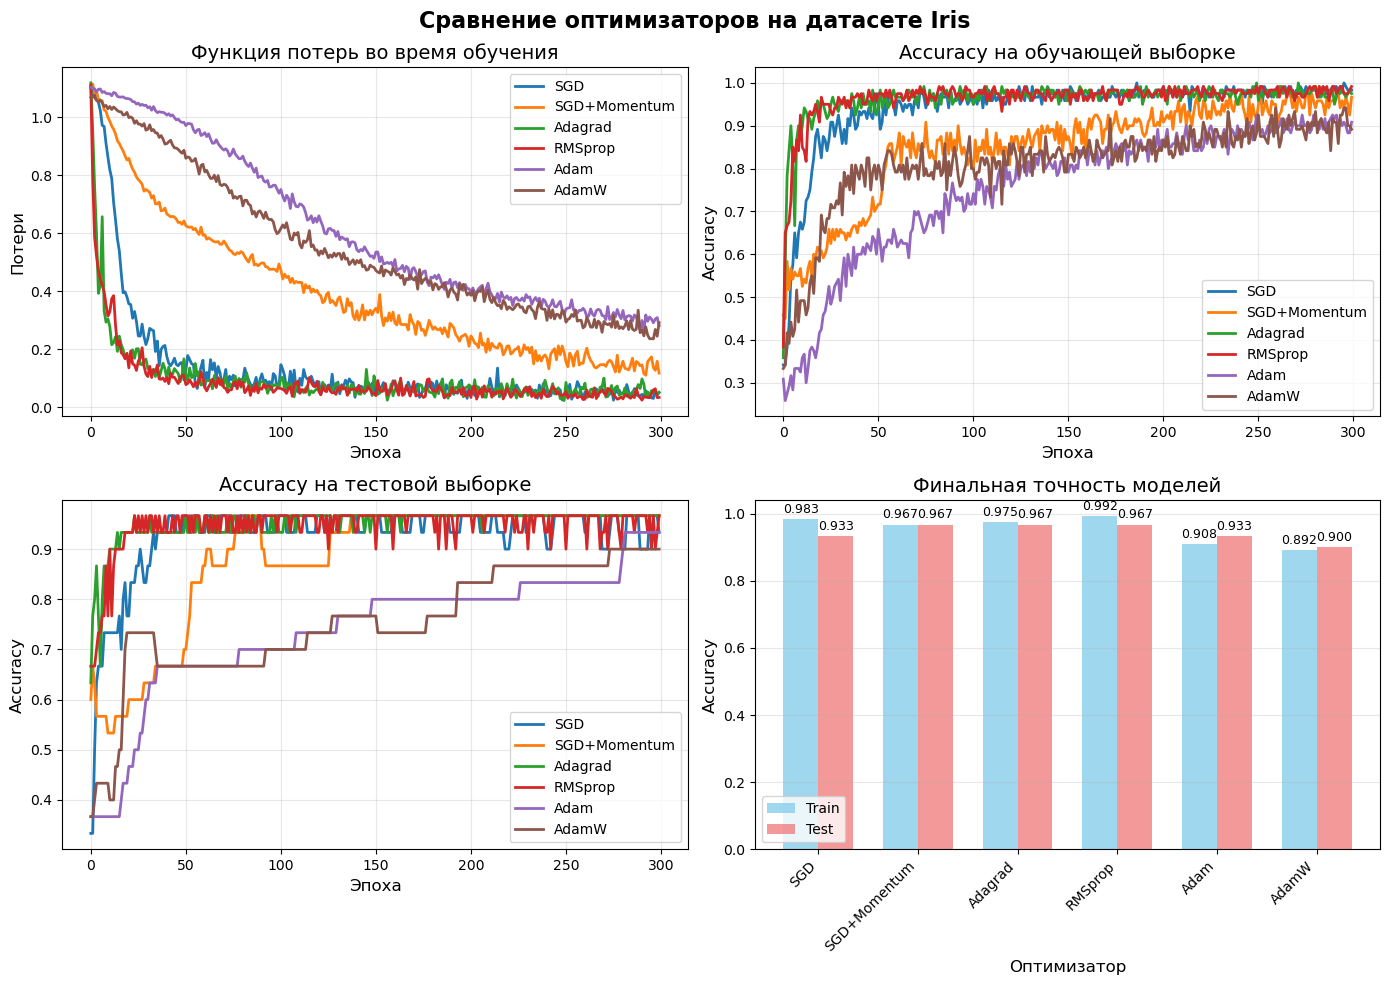

In [11]:
# 5. Визуализация результатов
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение оптимизаторов на датасете Iris', fontsize=16, fontweight='bold')

# График 1: Функция потерь
ax1 = axes[0, 0]
for result in results:
    ax1.plot(result['train_losses'], label=result['name'], linewidth=2)
ax1.set_xlabel('Эпоха', fontsize=12)
ax1.set_ylabel('Потери', fontsize=12)
ax1.set_title('Функция потерь во время обучения', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Accuracy на обучении
ax2 = axes[0, 1]
for result in results:
    ax2.plot(result['train_accuracies'], label=result['name'], linewidth=2)
ax2.set_xlabel('Эпоха', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy на обучающей выборке', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# График 3: Accuracy на тесте
ax3 = axes[1, 0]
for result in results:
    ax3.plot(result['test_accuracies'], label=result['name'], linewidth=2)
ax3.set_xlabel('Эпоха', fontsize=12)
ax3.set_ylabel('Accuracy', fontsize=12)
ax3.set_title('Accuracy на тестовой выборке', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)

# График 4: Сравнение финальных результатов
ax4 = axes[1, 1]
optimizer_names = [r['name'] for r in results]
final_test_accs = [r['final_test_acc'] for r in results]
final_train_accs = [r['final_train_acc'] for r in results]

x = np.arange(len(optimizer_names))
width = 0.35

bars1 = ax4.bar(x - width/2, final_train_accs, width, label='Train', alpha=0.8, color='skyblue')
bars2 = ax4.bar(x + width/2, final_test_accs, width, label='Test', alpha=0.8, color='lightcoral')

ax4.set_xlabel('Оптимизатор', fontsize=12)
ax4.set_ylabel('Accuracy', fontsize=12)
ax4.set_title('Финальная точность моделей', fontsize=14)
ax4.set_xticks(x)
ax4.set_xticklabels(optimizer_names, rotation=45, ha='right')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Добавим значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
# 6. Таблица сравнения
comparison_df = pd.DataFrame([{
    'Оптимизатор': r['name'],
    'Финальные потери': f"{r['final_loss']:.4f}",
    'Accuracy (train)': f"{r['final_train_acc']:.4f}",
    'Accuracy (test)': f"{r['final_test_acc']:.4f}",
    'Разница train-test': f"{abs(r['final_train_acc'] - r['final_test_acc']):.4f}",
    'Эпоха сходимости': next((i for i, acc in enumerate(r['test_accuracies'])
                             if acc > 0.95), epochs)  # когда достигли 95% accuracy
} for r in results])

# Сортируем по accuracy на тесте
comparison_df = comparison_df.sort_values('Accuracy (test)', ascending=False)
comparison_df

,Оптимизатор,Финальные потери,Accuracy (train),Accuracy (test),Разница train-test,Эпоха сходимости
1,SGD+Momentum,0.1176,0.9667,0.9667,0.0000,81
2,Adagrad,0.0512,0.9750,0.9667,0.0083,23
3,RMSprop,0.0336,0.9917,0.9667,0.0250,23
0,SGD,0.0498,0.9833,0.9333,0.0500,41
4,Adam,0.2810,0.9083,0.9333,0.0250,300
5,AdamW,0.2914,0.8917,0.9000,0.0083,300


In [13]:
# 7. Анализ результатов для этого случая
best_optimizer = comparison_df.iloc[0]['Оптимизатор']
best_test_acc = comparison_df.iloc[0]['Accuracy (test)']
print(f"Лучший оптимизатор: {best_optimizer} (Test Accuracy: {best_test_acc})")

Лучший оптимизатор: SGD+Momentum (Test Accuracy: 0.9667)


Наблюдения:
1. Adam/AdamW обычно сходятся дольше, но стабильнее
2. SGD требует больше эпох и правильного подбора learning rate
3. Adagrad может слишком быстро уменьшать learning rate для простых задач
4. Разница между train и test accuracy показывает степень переобучения
5. Для простых задач (как Iris) все оптимизаторы достигают хороших результатов

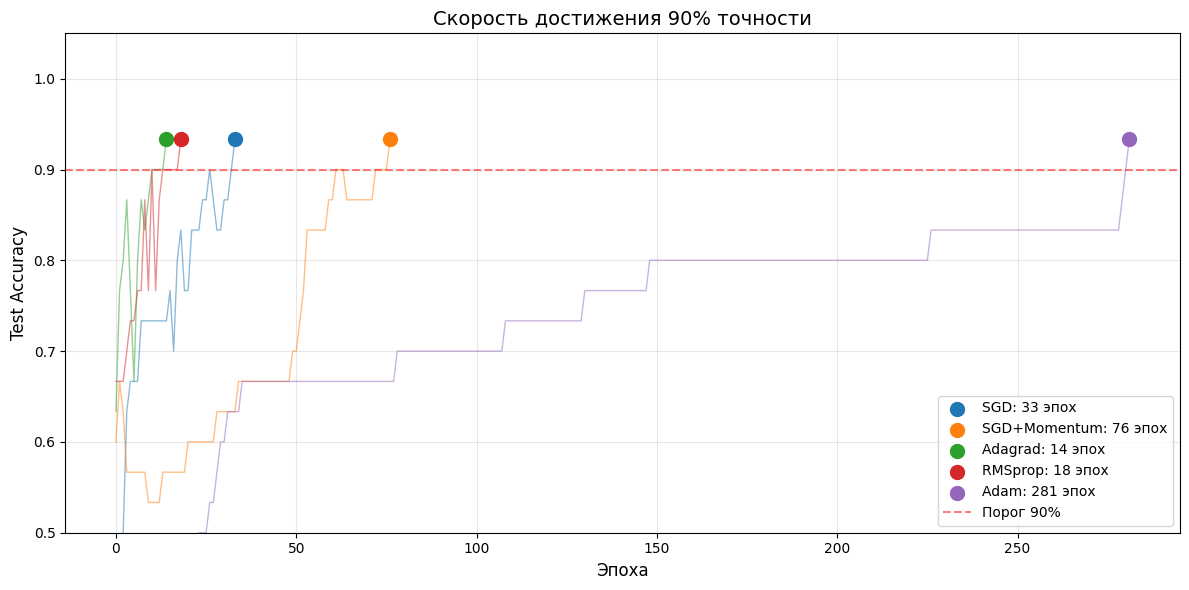

In [21]:
# 8. Дополнительно: Визуализация траектории обучения (упрощенная)
fig2, ax = plt.subplots(figsize=(12, 6))

# Найдем для каждого оптимизатора эпоху, когда впервые достигли 90% accuracy
for result in results:
    # Ищем первую эпоху с accuracy > 0.9
    for epoch, acc in enumerate(result['test_accuracies']):
        if acc >= 0.9:
            ax.scatter(epoch, acc, s=100, label=f"{result['name']}: {epoch} эпох", zorder=5)
            # Линия от начала до точки сходимости
            ax.plot(result['test_accuracies'][:epoch+1], alpha=0.5, linewidth=1)
            break

ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Порог 90%')
ax.set_xlabel('Эпоха', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Скорость достижения 90% точности', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.05])

plt.tight_layout()
plt.show()